In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('/content/Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [39]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [41]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [42]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [43]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200, 5)


In [44]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [45]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [46]:
print(df['Sales'].describe())

count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales, dtype: float64


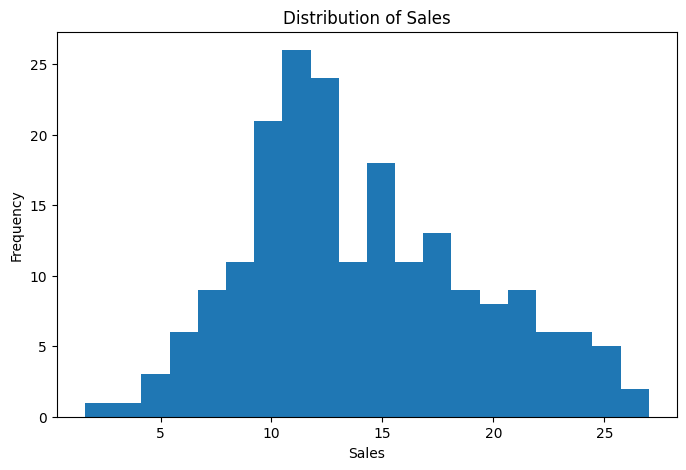

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(df['Sales'], bins=20)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

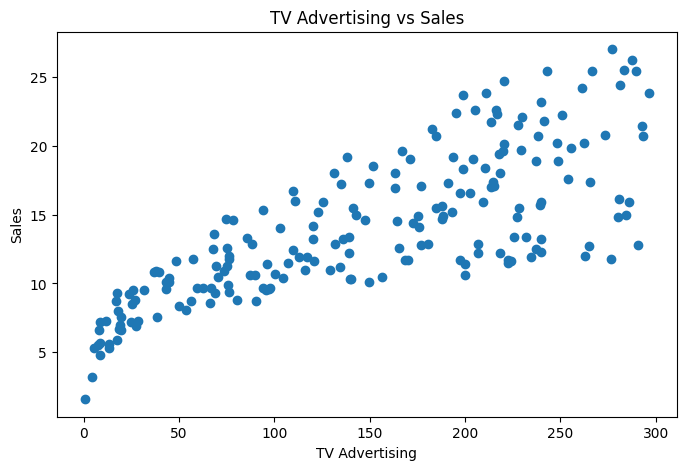

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(df['TV'], df['Sales'])

plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising')
plt.ylabel('Sales')

plt.show()

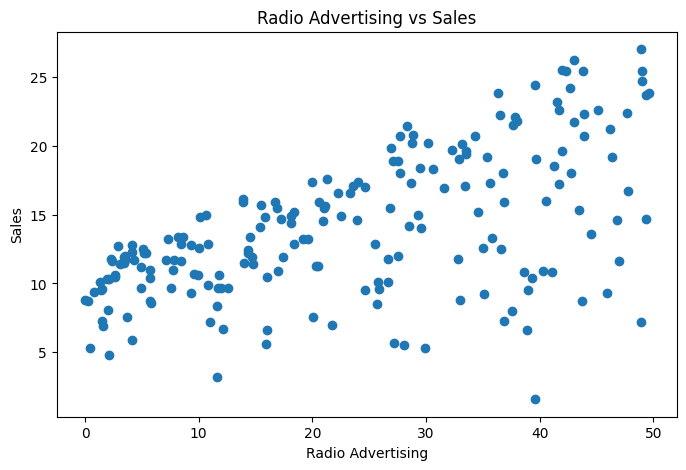

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Radio'], df['Sales'])

plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')

plt.show()

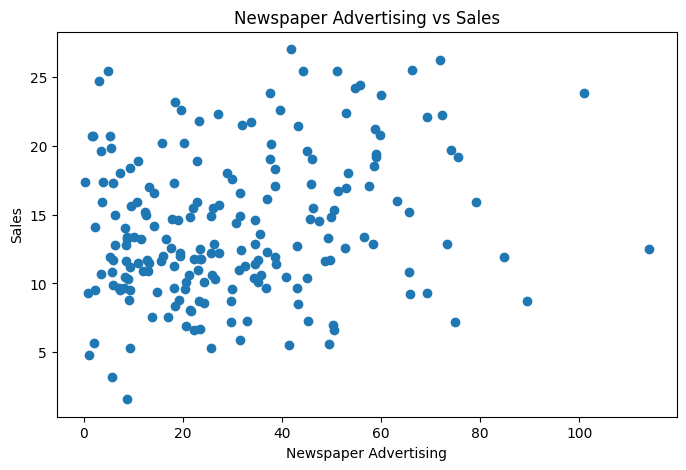

In [50]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Newspaper'], df['Sales'])

plt.title('Newspaper Advertising vs Sales')
plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')

plt.show()

In [51]:
correlation = df.corr()

print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


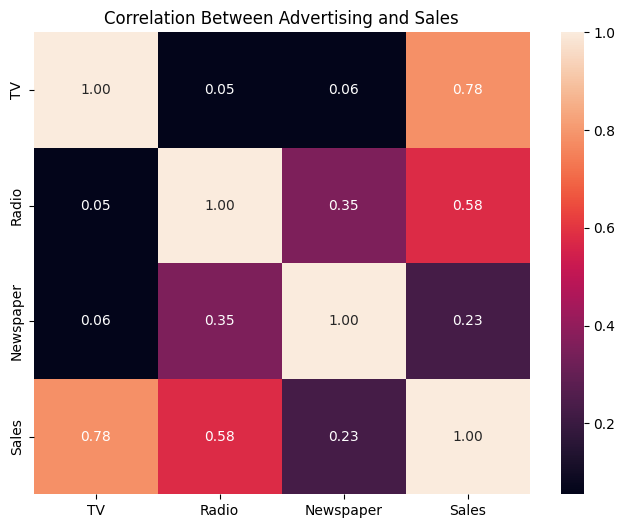

In [52]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Advertising and Sales')

plt.show()

In [53]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [55]:
model = LinearRegression()

In [56]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [57]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [58]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.4607567168117603


In [59]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3.1740973539761033


In [60]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.78159966153345


In [61]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.899438024100912


In [62]:
print("Model Evaluation")
print("-------------------------")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

Model Evaluation
-------------------------
MAE : 1.46
MSE : 3.17
RMSE: 1.78
R²  : 0.9


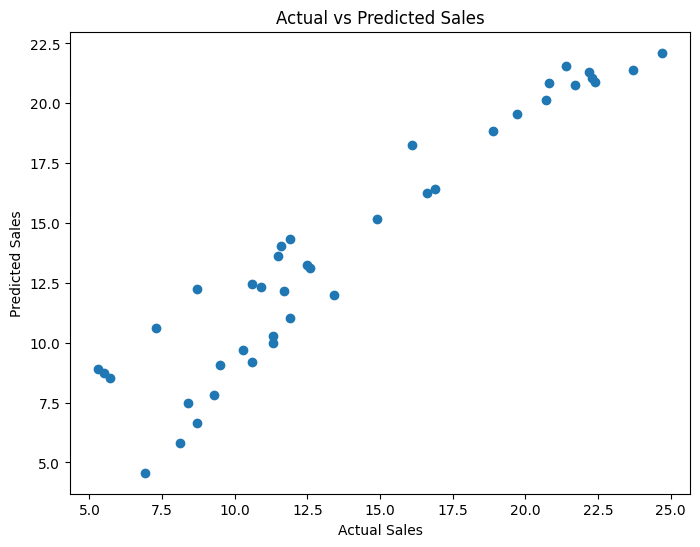

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

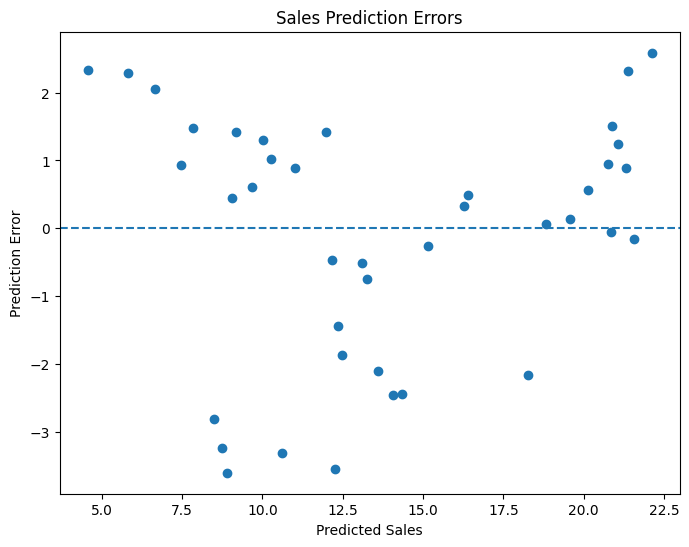

In [64]:
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Sales')
plt.ylabel('Prediction Error')
plt.title('Sales Prediction Errors')

plt.show()

In [65]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


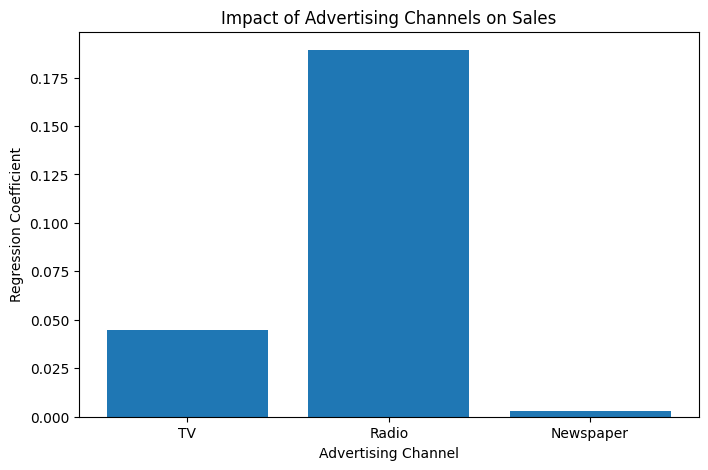

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.xlabel('Advertising Channel')
plt.ylabel('Regression Coefficient')
plt.title('Impact of Advertising Channels on Sales')

plt.show()

In [67]:
new_advertising = pd.DataFrame({
    'TV': [150],
    'Radio': [30],
    'Newspaper': [20]
})

predicted_sales = model.predict(new_advertising)

print(
    "Predicted Sales:",
    round(predicted_sales[0], 2)
)

Predicted Sales: 15.42


## Key Insights

1. The dataset contains 200 records and 5 columns: TV, Radio,
   Newspaper, Sales, and an index column. The index column was
   removed because it does not provide useful information for
   predicting sales.

2. The dataset contains no missing values and no duplicate records,
   making it suitable for further analysis and model development.

3. The average Sales value in the dataset is 14.02, with observed
   sales ranging from 1.60 to 27.00.

4. TV advertising has the strongest correlation with Sales, with a
   correlation coefficient of 0.78. This indicates a strong positive
   relationship between TV advertising expenditure and sales.

5. Radio advertising also has a positive relationship with Sales,
   with a correlation coefficient of 0.58, indicating a moderate
   positive relationship.

6. Newspaper advertising has a weaker relationship with Sales,
   with a correlation coefficient of 0.23.

7. The Linear Regression model was trained using 160 records and
   evaluated on 40 test records using an 80/20 train-test split.

8. The model achieved an MAE of 1.46, meaning that the predicted
   sales differ from the actual sales by about 1.46 units on average.

9. The model achieved an RMSE of 1.78 and an R² score of 0.90.
   The R² score indicates that approximately 90% of the variation
   in sales in the test data is explained by the model.

10. The regression coefficients were 0.0447 for TV, 0.1892 for
    Radio, and 0.0028 for Newspaper. Among the three variables,
    Radio has the largest regression coefficient in the fitted
    model, while Newspaper has the smallest.

11. For an example advertising budget of TV = 150, Radio = 30,
    and Newspaper = 20, the model predicted sales of approximately
    15.42.

12. Overall, the analysis demonstrates that advertising expenditure,
    particularly TV and Radio advertising, can be useful for
    predicting sales and supporting data-driven marketing decisions.

## Conclusion

This project developed a Linear Regression model to predict sales
using advertising expenditure on TV, Radio, and Newspaper.

The dataset was first inspected and cleaned. It contained 200 records,
with no missing values or duplicate records. The unnecessary index
column was removed before performing the analysis.

Exploratory data analysis showed that TV advertising had the strongest
correlation with Sales (0.78), followed by Radio (0.58), while
Newspaper had a weaker correlation (0.23).

A Linear Regression model was trained using an 80/20 train-test split.
The model achieved an MAE of 1.46, an MSE of 3.17, an RMSE of 1.78,
and an R² score of 0.90.

The model was also used to predict sales for a new advertising budget
of TV = 150, Radio = 30, and Newspaper = 20, resulting in a predicted
sales value of 15.42.

Overall, the project demonstrates how machine learning can be applied
to historical advertising data to predict sales and support
data-driven advertising and marketing decisions.

In [68]:
import joblib

joblib.dump(
    model,
    'sales_prediction_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!
